# Assignment 04 — Decision Tree ID3
**Author:** Wiktor Sosnowski, 348561  
**Dataset:** Tic-Tac-Toe Endgame (UCI ML Repository)

## 0. Imports and configuration

In [3]:
# Author: Wiktor Sosnowski, 348561

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Add src to path so id3 module is importable
sys.path.insert(0, '../../src/assignment_04')
from id3 import DecisionTreeID3, accuracy, confusion_matrix

# Output directories
RESULTS_DIR = os.path.join('..', 'data', 'processed', 'assignment_04')
PLOTS_DIR   = os.path.join('..', 'data', 'processed', 'assignment_04')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Reproducibility
N_RUNS = 25
SEEDS  = list(range(N_RUNS))  # seeds 0..24

print('Setup complete.')

Setup complete.


## 1. Load and inspect data

In [5]:
DATA_PATH = os.path.join('..', '..', 'data', 'assignment_04', 'raw', 'tic-tac-toe.data')

# Column names from UCI documentation
col_names = [
    'top-left', 'top-middle', 'top-right',
    'middle-left', 'middle-middle', 'middle-right',
    'bottom-left', 'bottom-middle', 'bottom-right',
    'class'
]

df = pd.read_csv(DATA_PATH, header=None, names=col_names)

print(f'Dataset shape: {df.shape}')
print(f'Class distribution:\n{df["class"].value_counts()}')
print(f'\nSample rows:')
df.head()

Dataset shape: (958, 10)
Class distribution:
class
positive    626
negative    332
Name: count, dtype: int64

Sample rows:


,top-left,top-middle,top-right,middle-left,middle-middle,middle-right,bottom-left,bottom-middle,bottom-right,class
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


## 2. Data preparation utilities

In [6]:
def prepare_data(df, target_col='class'):
    """Split dataframe into feature matrix X and label array y."""
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    return X, y


def train_val_test_split(X, y, train_ratio, val_ratio, seed):
    """
    Split data into train / validation / test sets.
    test_ratio = 1 - train_ratio - val_ratio
    """
    rng = np.random.default_rng(seed)
    n = len(y)
    indices = rng.permutation(n)

    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_idx = indices[:n_train]
    val_idx   = indices[n_train:n_train + n_val]
    test_idx  = indices[n_train + n_val:]

    return (
        X[train_idx], y[train_idx],
        X[val_idx],   y[val_idx],
        X[test_idx],  y[test_idx]
    )


def run_experiment(X, y, max_depth, train_ratio, val_ratio, seeds):
    """
    Run N_RUNS trials with different random splits.
    Returns dict with lists of val_acc and test_acc across runs.
    """
    val_accs  = []
    test_accs = []

    for seed in seeds:
        X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
            X, y, train_ratio, val_ratio, seed
        )
        clf = DecisionTreeID3(max_depth=max_depth)
        clf.fit(X_train, y_train)

        val_accs.append(accuracy(y_val, clf.predict(X_val)))
        test_accs.append(accuracy(y_test, clf.predict(X_test)))

    return {'val_acc': val_accs, 'test_acc': test_accs}


def aggregate_stats(values):
    """Return (min, mean, std, max) rounded to 4 decimal places."""
    arr = np.array(values)
    return arr.min(), arr.mean(), arr.std(), arr.max()


print('Utilities defined.')

Utilities defined.


In [7]:
X, y = prepare_data(df)
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Unique classes: {np.unique(y)}')

X shape: (958, 9), y shape: (958,)
Unique classes: ['negative' 'positive']


## 3. Experiment 1 — Effect of max_depth

**Fixed parameters:** train/val/test split = 70/15/15, 25 random splits (seeds 0–24)  
**Varied parameter:** max_depth ∈ {1, 2, 3, 4, 5, 6, 7, 8, 9, None}

In [8]:
TRAIN_RATIO_E1 = 0.70
VAL_RATIO_E1   = 0.15
DEPTH_VALUES   = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]

exp1_rows = []

for depth in DEPTH_VALUES:
    results = run_experiment(X, y, max_depth=depth,
                             train_ratio=TRAIN_RATIO_E1,
                             val_ratio=VAL_RATIO_E1,
                             seeds=SEEDS)

    v_min, v_mean, v_std, v_max = aggregate_stats(results['val_acc'])
    t_min, t_mean, t_std, t_max = aggregate_stats(results['test_acc'])

    label = str(depth) if depth is not None else 'None'
    exp1_rows.append({
        'max_depth': label,
        'val_min':  round(v_min,  4), 'val_mean':  round(v_mean,  4),
        'val_std':  round(v_std,  4), 'val_max':   round(v_max,   4),
        'test_min': round(t_min,  4), 'test_mean': round(t_mean,  4),
        'test_std': round(t_std,  4), 'test_max':  round(t_max,   4),
    })
    print(f'depth={label:>4}  val_mean={v_mean:.4f}  test_mean={t_mean:.4f}')

df_exp1 = pd.DataFrame(exp1_rows)
df_exp1

depth=   1  val_mean=0.7060  test_mean=0.6910
depth=   2  val_mean=0.6738  test_mean=0.6756
depth=   3  val_mean=0.7385  test_mean=0.7377
depth=   4  val_mean=0.7908  test_mean=0.7843
depth=   5  val_mean=0.8495  test_mean=0.8433
depth=   6  val_mean=0.8596  test_mean=0.8568
depth=   7  val_mean=0.8618  test_mean=0.8590
depth=   8  val_mean=0.8618  test_mean=0.8590
depth=   9  val_mean=0.8618  test_mean=0.8590
depth=None  val_mean=0.8618  test_mean=0.8590


,max_depth,val_min,val_mean,val_std,val_max,test_min,test_mean,test_std,test_max
0,1,0.6573,0.7060,0.0373,0.7902,0.6483,0.6910,0.0285,0.7517
1,2,0.6014,0.6738,0.0367,0.7413,0.6069,0.6756,0.0340,0.7310
2,3,0.6853,0.7385,0.0298,0.8182,0.6828,0.7377,0.0267,0.7862
3,4,0.7343,0.7908,0.0334,0.8531,0.6966,0.7843,0.0375,0.8621
4,5,0.7692,0.8495,0.0346,0.9091,0.7793,0.8433,0.0308,0.9172
5,6,0.7832,0.8596,0.0386,0.9371,0.7931,0.8568,0.0284,0.9034
6,7,0.7972,0.8618,0.0366,0.9441,0.7931,0.8590,0.0302,0.9103
7,8,0.7972,0.8618,0.0366,0.9441,0.7931,0.8590,0.0302,0.9103
8,9,0.7972,0.8618,0.0366,0.9441,0.7931,0.8590,0.0302,0.9103
9,None,0.7972,0.8618,0.0366,0.9441,0.7931,0.8590,0.0302,0.9103


In [9]:
# Save experiment 1 results
df_exp1.to_csv(os.path.join(RESULTS_DIR, 'experiment1_depth.csv'), index=False)
print('Saved experiment1_depth.csv')

Saved experiment1_depth.csv


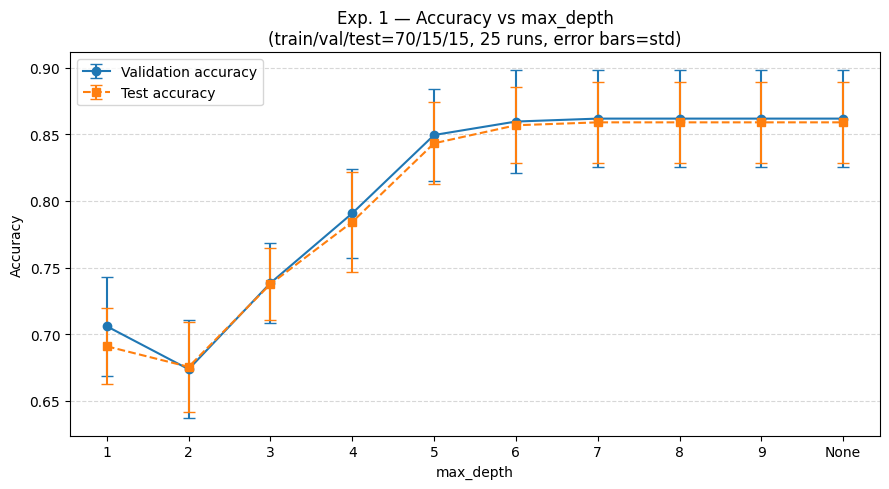

Saved exp1_depth_accuracy.png


In [10]:
# Plot experiment 1
x_labels = [str(d) if d is not None else 'None' for d in DEPTH_VALUES]
x_pos    = list(range(len(DEPTH_VALUES)))

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(x_pos, df_exp1['val_mean'],  yerr=df_exp1['val_std'],
            fmt='o-', label='Validation accuracy', capsize=4)
ax.errorbar(x_pos, df_exp1['test_mean'], yerr=df_exp1['test_std'],
            fmt='s--', label='Test accuracy', capsize=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title(
    'Exp. 1 — Accuracy vs max_depth\n'
    '(train/val/test=70/15/15, 25 runs, error bars=std)'
)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'exp1_depth_accuracy.png'), dpi=150)
plt.show()
print('Saved exp1_depth_accuracy.png')

## 4. Experiment 2 — Effect of train set size

**Fixed parameters:** max_depth = best value from Experiment 1, val_ratio = half of remaining data, 25 random splits (seeds 0–24)  
**Varied parameter:** train_ratio ∈ {0.50, 0.60, 0.70, 0.80, 0.90}

In [11]:
# --- Set best depth from Experiment 1 here after reviewing results ---
# Choose the depth with the highest test_mean (or val_mean if test is unavailable at selection time)
BEST_DEPTH = int(df_exp1.loc[df_exp1['test_mean'].idxmax(), 'max_depth'].replace('None', '0') or 0)
BEST_DEPTH = None if BEST_DEPTH == 0 else BEST_DEPTH
print(f'Best depth selected from Exp. 1: {BEST_DEPTH}')

TRAIN_RATIOS = [0.50, 0.60, 0.70, 0.80, 0.90]
# val_ratio = half of what remains after train, so test_ratio = same

exp2_rows = []

for train_ratio in TRAIN_RATIOS:
    val_ratio = (1.0 - train_ratio) / 2.0
    results = run_experiment(X, y, max_depth=BEST_DEPTH,
                             train_ratio=train_ratio,
                             val_ratio=val_ratio,
                             seeds=SEEDS)

    t_min, t_mean, t_std, t_max = aggregate_stats(results['test_acc'])

    exp2_rows.append({
        'train_ratio': train_ratio,
        'test_min':  round(t_min,  4),
        'test_mean': round(t_mean, 4),
        'test_std':  round(t_std,  4),
        'test_max':  round(t_max,  4),
    })
    print(f'train_ratio={train_ratio:.2f}  test_mean={t_mean:.4f}  test_std={t_std:.4f}')

df_exp2 = pd.DataFrame(exp2_rows)
df_exp2

Best depth selected from Exp. 1: 7
train_ratio=0.50  test_mean=0.8328  test_std=0.0288
train_ratio=0.60  test_mean=0.8479  test_std=0.0243
train_ratio=0.70  test_mean=0.8590  test_std=0.0302
train_ratio=0.80  test_mean=0.8590  test_std=0.0338
train_ratio=0.90  test_mean=0.8514  test_std=0.0515


,train_ratio,test_min,test_mean,test_std,test_max
0,0.5,0.7583,0.8328,0.0288,0.8792
1,0.6,0.7772,0.8479,0.0243,0.8912
2,0.7,0.7931,0.8590,0.0302,0.9103
3,0.8,0.7835,0.8590,0.0338,0.9072
4,0.9,0.7347,0.8514,0.0515,0.9388


In [12]:
# Save experiment 2 results
df_exp2.to_csv(os.path.join(RESULTS_DIR, 'experiment2_split.csv'), index=False)
print('Saved experiment2_split.csv')

Saved experiment2_split.csv


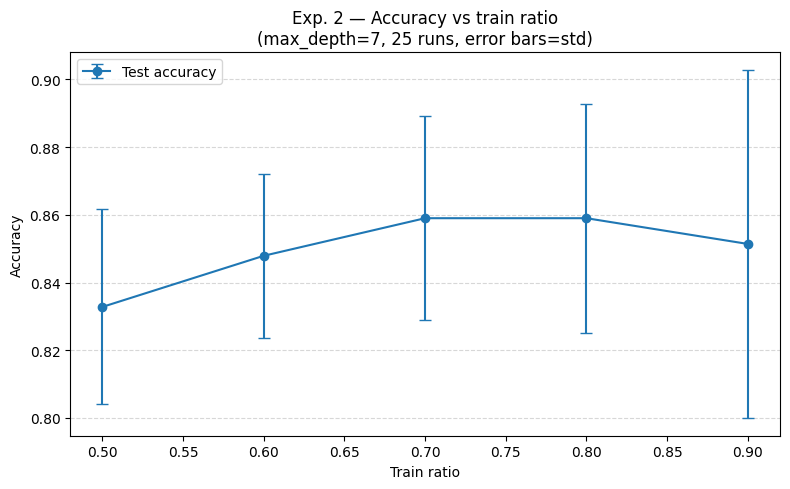

Saved exp2_split_accuracy.png


In [13]:
# Plot experiment 2
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(df_exp2['train_ratio'], df_exp2['test_mean'], yerr=df_exp2['test_std'],
            fmt='o-', capsize=4, label='Test accuracy')

ax.set_xlabel('Train ratio')
ax.set_ylabel('Accuracy')
ax.set_title(
    f'Exp. 2 — Accuracy vs train ratio\n'
    f'(max_depth={BEST_DEPTH}, 25 runs, error bars=std)'
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'exp2_split_accuracy.png'), dpi=150)
plt.show()
print('Saved exp2_split_accuracy.png')

## 5. Confusion matrix — best model

**Parameters:** max_depth = best from Exp. 1, train_ratio = best from Exp. 2  
**Evaluated on:** test set, single run with seed=0

In [14]:
# Select best train_ratio from Experiment 2
BEST_TRAIN_RATIO = float(df_exp2.loc[df_exp2['test_mean'].idxmax(), 'train_ratio'])
BEST_VAL_RATIO   = (1.0 - BEST_TRAIN_RATIO) / 2.0
print(f'Best train_ratio: {BEST_TRAIN_RATIO}')
print(f'Best depth:       {BEST_DEPTH}')

# Single fixed split for the confusion matrix (seed=0)
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
    X, y, BEST_TRAIN_RATIO, BEST_VAL_RATIO, seed=0
)

clf_best = DecisionTreeID3(max_depth=BEST_DEPTH)
clf_best.fit(X_train, y_train)
y_pred = clf_best.predict(X_test)

test_acc = accuracy(y_test, y_pred)
print(f'Test accuracy (seed=0): {test_acc:.4f}')

cm, classes = confusion_matrix(y_test, y_pred)
print(f'Classes: {classes}')
print('Confusion matrix:')
print(cm)

Best train_ratio: 0.7
Best depth:       7
Test accuracy (seed=0): 0.8069
Classes: ['negative', 'positive']
Confusion matrix:
[[36 18]
 [10 81]]


In [15]:
# Save confusion matrix to CSV
df_cm = pd.DataFrame(cm, index=classes, columns=classes)
df_cm.to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix.csv'))
print('Saved confusion_matrix.csv')

Saved confusion_matrix.csv


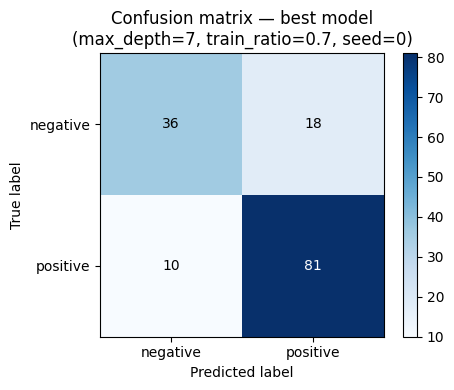

Saved confusion_matrix.png


In [16]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(
    f'Confusion matrix — best model\n'
    f'(max_depth={BEST_DEPTH}, train_ratio={BEST_TRAIN_RATIO}, seed=0)'
)

# Annotate cells
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print('Saved confusion_matrix.png')